In [3]:
%pip install tensorflow pillow numpy matplotlib keras

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import keras

SEED = 42
np.random.seed(SEED)

DATA_ROOT = Path('../Pythia')
ATTACK_NAMES = ['attack_a', 'attack_b', 'attack_c', 'attack_d',
                'attack_e', 'attack_f', 'attack_g', 'attack_h']

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


## Architektura modelu

In [4]:
def build_model():
    return keras.Sequential([
        keras.layers.Input(shape=(21, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(16, activation='swish'),
        keras.layers.Dense(10, activation='softmax'),
    ])

model = build_model()
model.summary()

total_weights = sum(w.size for w in model.get_weights())
print(f'Laczna liczba wag: {total_weights}')
print(f'Bajty na model:    {total_weights * 4}')
print(f'Pikseli w obrazie: {70*70}')
print(f'Padding:           {70*70 - total_weights * 4}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194 (4.66 KB)

 Trainable params: 1,194 (4.66 KB)

 Non-trainable params: 0 (0.00 B)

Laczna liczba wag: 1194
Bajty na model:    4776
Pikseli w obrazie: 4900
Padding:           124


## Dekodowanie wag z obrazu

In [6]:
def decode_weights(image):
    pixels = np.asarray(image, dtype=np.uint8).flatten()
    weights_bytes = pixels[:4776].tobytes()
    weights = np.frombuffer(weights_bytes, dtype='>f4').astype(np.float32)
    return weights

def load_weights_into_model(model, weights):
    ref = model.get_weights()
    parts = np.split(weights, np.cumsum([w.size for w in ref[:-1]]))
    model.set_weights([p.reshape(w.shape) for p, w in zip(parts, ref)])

def load_model_from_path(image_path):
    img = Image.open(image_path).convert('L') # Wczytywanie PNG jako grayscale (70x70, uint8)
    m = build_model()
    load_weights_into_model(m, decode_weights(img))
    return m

## Rozkłady ppb dla randomowego batcha danych

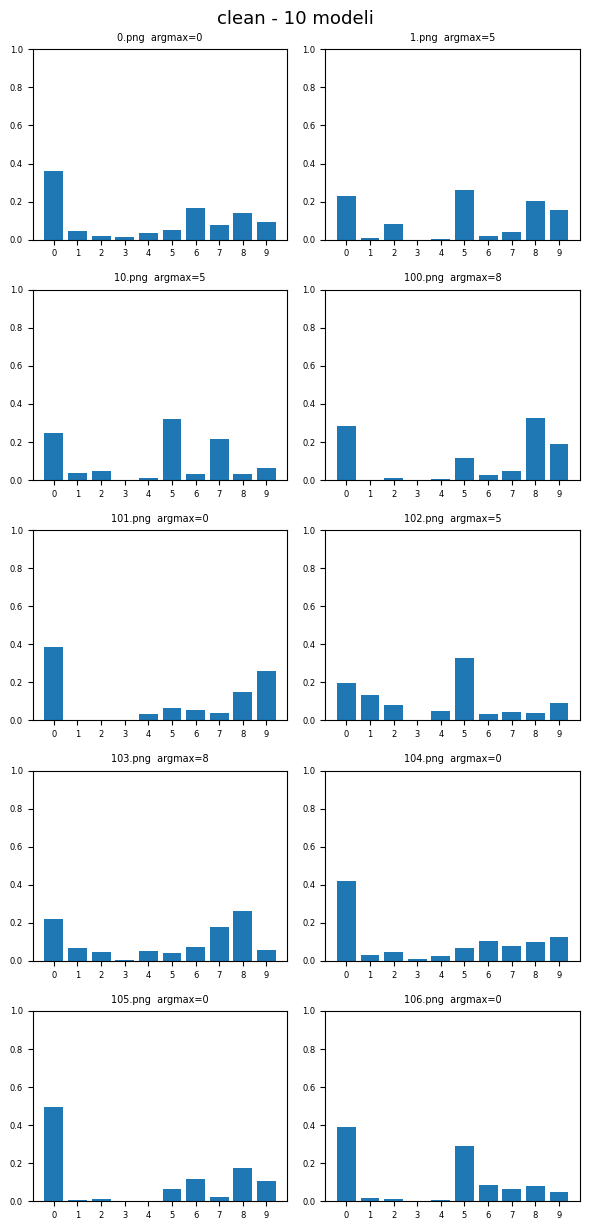

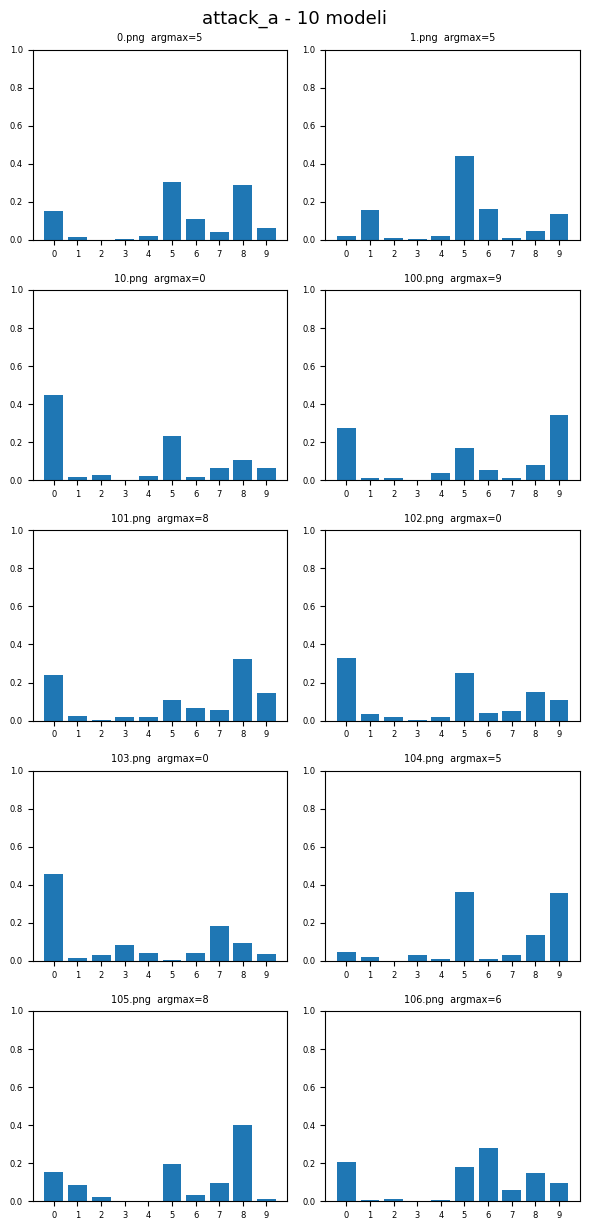

In [14]:
rng = np.random.default_rng(SEED)
test_input = rng.random((1, 21, 3)).astype(np.float32)

N = 10
COLS = 2

def plot_probs_grid(paths, title):
    paths = list(paths)
    rows = (len(paths) + COLS - 1) // COLS
    fig, axes = plt.subplots(rows, COLS, figsize=(3 * COLS, 2.5 * rows))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=13)
    for i, path in enumerate(paths):
        probs = load_model_from_path(path).predict(test_input, verbose=0)[0]
        axes[i].bar(range(10), probs)
        axes[i].set_title(f'{path.name}  argmax={probs.argmax()}', fontsize=7)
        axes[i].set_ylim(0, 1)
        axes[i].set_xticks(range(10))
        axes[i].tick_params(labelsize=6)
    for k in range(i + 1, len(axes)):
        axes[k].axis('off')
    plt.tight_layout()
    plt.show()

clean_paths  = sorted((DATA_ROOT / 'clean').glob('*.png'))[:N]
attack_paths = sorted((DATA_ROOT / 'attack_a').glob('*.png'))[:N]

plot_probs_grid(clean_paths,  f'clean - {N} modeli')
plot_probs_grid(attack_paths, f'attack_a - {N} modeli')

## Porownanie clean vs attack - rozklady prawdopodobienstwa

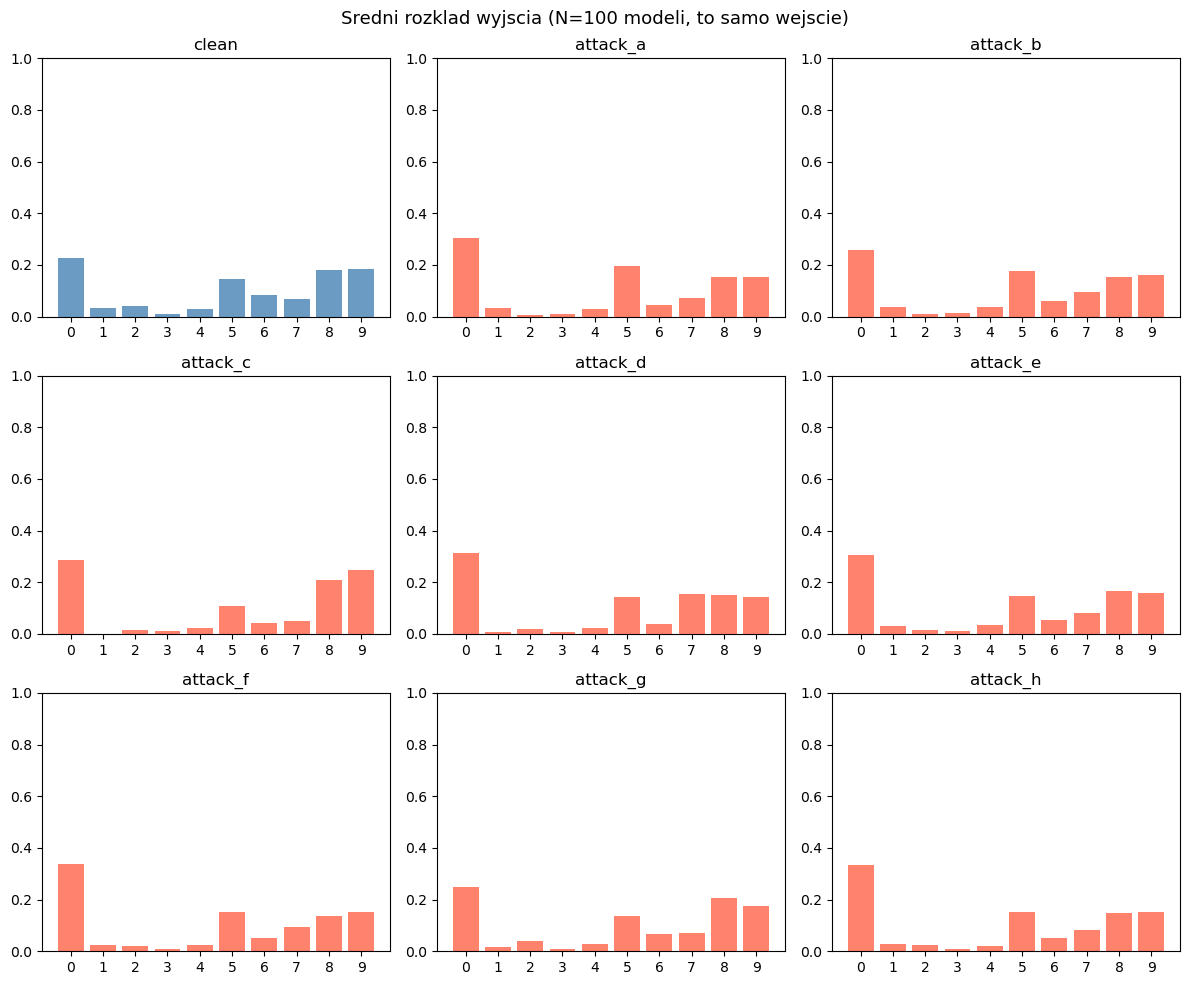

In [17]:
N_PER_CLASS = 100
classes = ['clean'] + ATTACK_NAMES

all_probs = {}
for cls in classes:
    files = sorted((DATA_ROOT / cls).glob('*.png'))[:N_PER_CLASS]
    all_probs[cls] = np.array([
        load_model_from_path(p).predict(test_input, verbose=0)[0]
        for p in files
    ])

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
colors = ['steelblue'] + ['tomato'] * len(ATTACK_NAMES)

for i, cls in enumerate(classes):
    mean_p = all_probs[cls].mean(axis=0)
    ax = axes[i]
    ax.bar(range(10), mean_p, color=colors[i], alpha=0.8)
    ax.set_title(cls)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(10))

plt.suptitle(f'Sredni rozklad wyjscia (N={N_PER_CLASS} modeli, to samo wejscie)', fontsize=13)
plt.tight_layout()
plt.show()

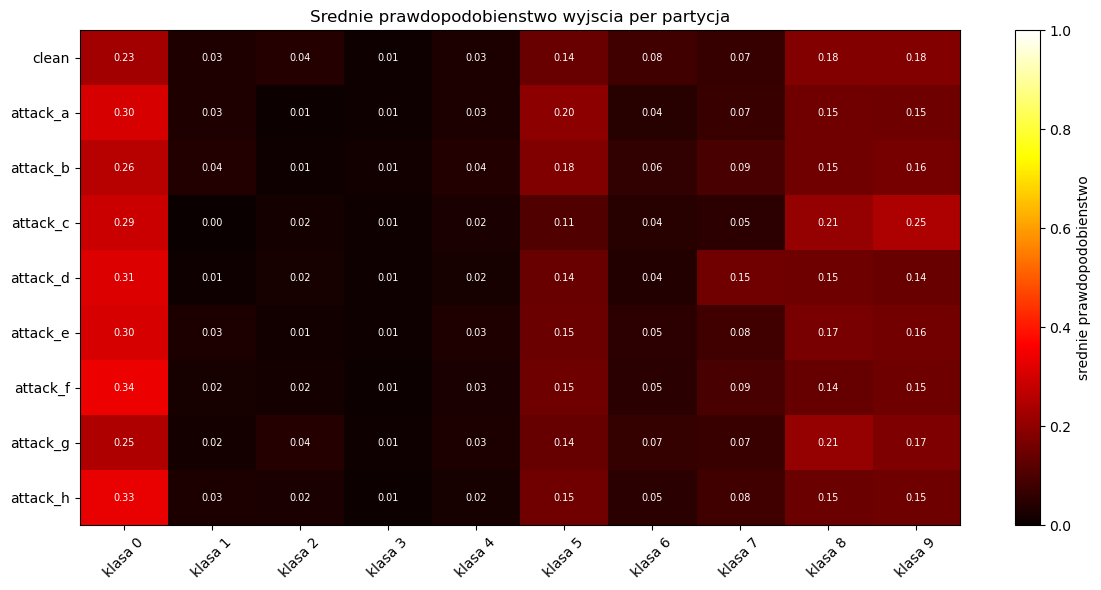

In [20]:
mean_matrix = np.array([all_probs[cls].mean(axis=0) for cls in classes])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mean_matrix, aspect='auto', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='srednie prawdopodobienstwo')
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes)
ax.set_xticks(range(10))
ax.set_xticklabels([f'klasa {k}' for k in range(10)], rotation=45)
ax.set_title('Srednie prawdopodobienstwo wyjscia per partycja')

for i in range(len(classes)):
    for j in range(10):
        ax.text(j, i, f'{mean_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if mean_matrix[i,j] < 0.5 else 'black')

plt.tight_layout()
plt.show()

## One pixel signature

X shape: (1800, 630), clean: 200, attack: 1600


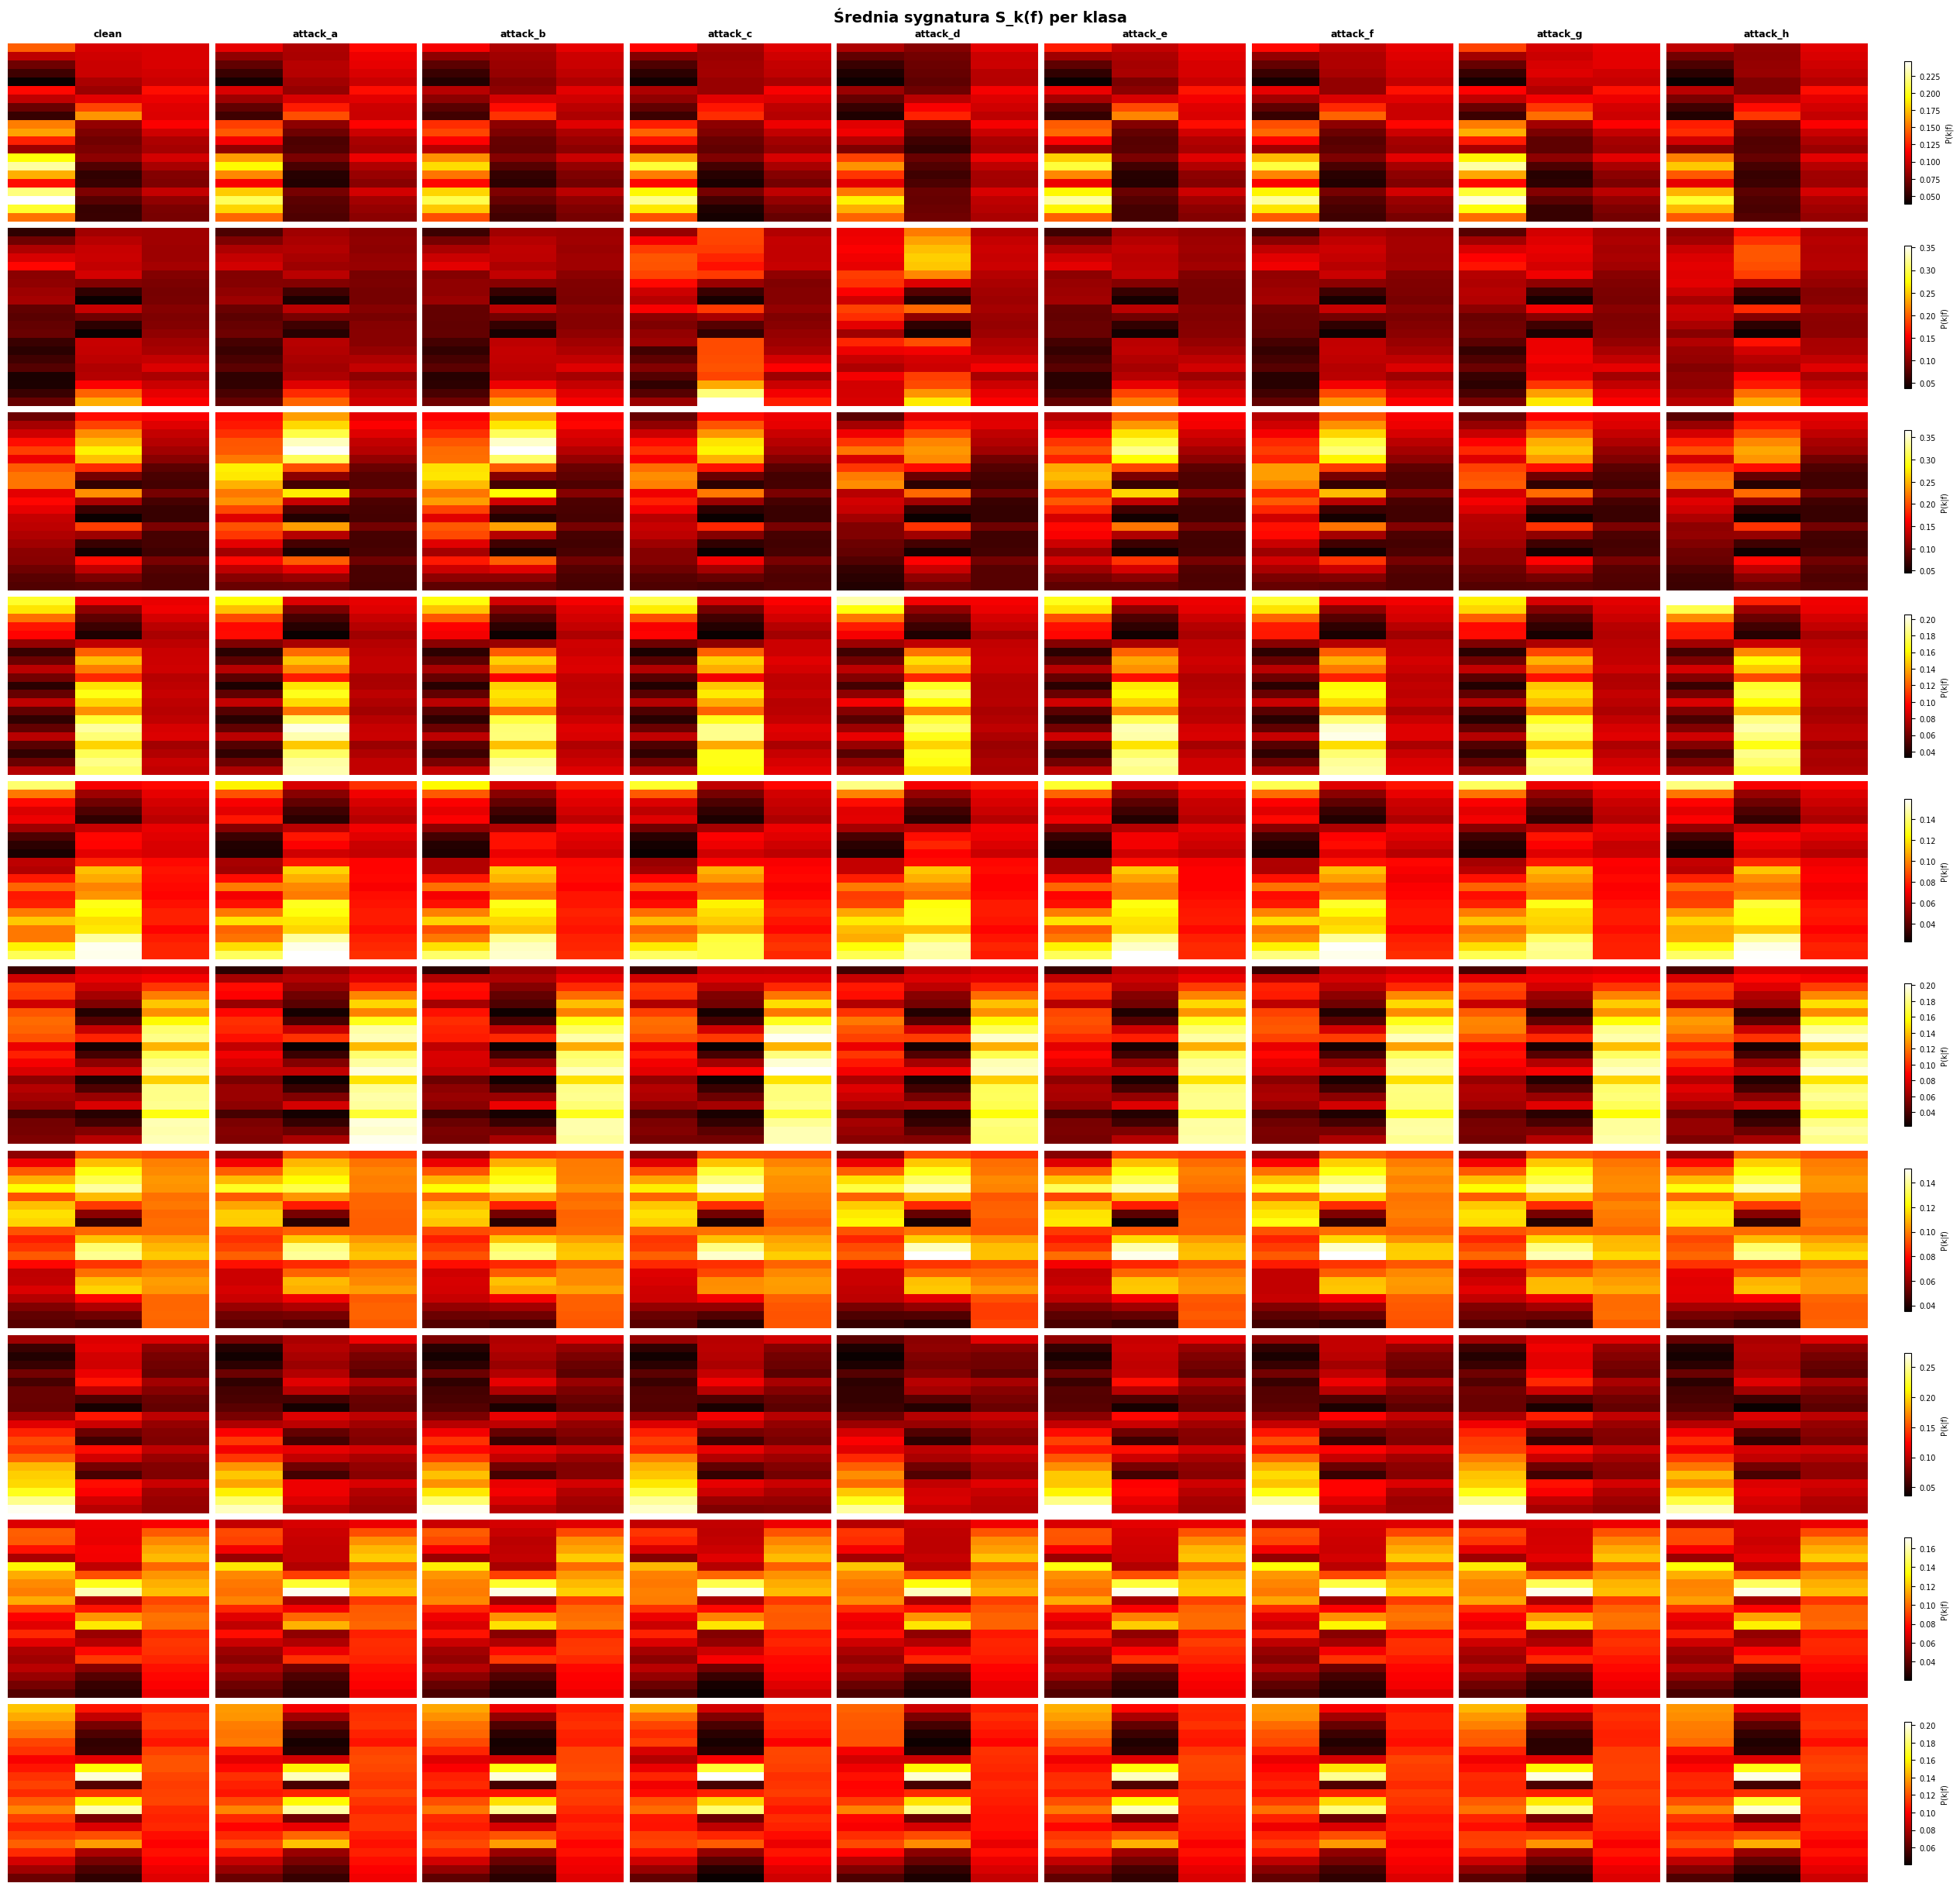

              precision    recall  f1-score   support

       clean       0.62      0.72      0.67        40
      attack       0.96      0.94      0.95       320

    accuracy                           0.92       360
   macro avg       0.79      0.83      0.81       360
weighted avg       0.93      0.92      0.92       360



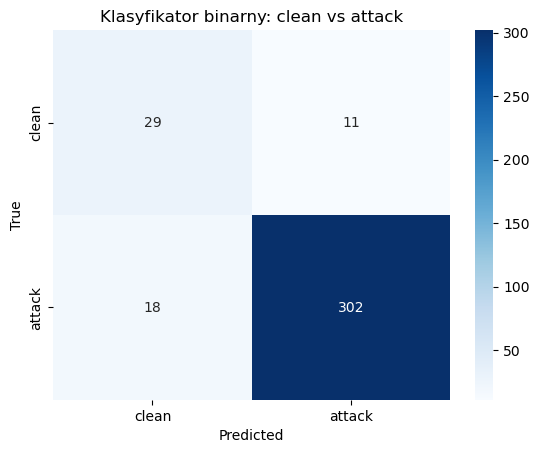

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

N_PER_CLASS = 200
classes = ['clean'] + ATTACK_NAMES

def model_signature(path):
    m = load_model_from_path(path)
    feats = []
    for i in range(21):
        for j in range(3):
            inp = np.zeros((1, 21, 3), dtype=np.float32)
            inp[0, i, j] = 1.0
            feats.extend(m.predict(inp, verbose=0)[0])
    return np.array(feats, dtype=np.float32)

X, y, paths_all = [], [], []
for cls in classes:
    label = 0 if cls == 'clean' else 1
    for path in sorted((DATA_ROOT / cls).glob('*.png'))[:N_PER_CLASS]:
        X.append(model_signature(path))
        y.append(label)
        paths_all.append((cls, path.name))

X = np.array(X)
y = np.array(y)
print(f'X shape: {X.shape}, clean: {(y==0).sum()}, attack: {(y==1).sum()}')

X_maps = X.reshape(-1, 21, 3, 10)

sig_per_cls = {}
for cls_id, cls in enumerate(classes):
    mask = np.array([1 if p[0] == cls else 0 for p in paths_all], dtype=bool)
    sig_per_cls[cls] = X_maps[mask].mean(axis=0)  # (21, 3, 10)

n_cls = len(classes)
n_k   = 10

fig, axes = plt.subplots(
    n_k, n_cls,
    figsize=(2.8 * n_cls, 2.4 * n_k),
    constrained_layout=True
)
fig.suptitle('Średnia sygnatura S_k(f) per klasa', fontsize=14, fontweight='bold', y=1.01)

# nagłówki kolumn
for cls_id, cls in enumerate(classes):
    axes[0, cls_id].set_title(cls, fontsize=9, fontweight='bold')

for k in range(n_k):
    vals = np.stack([sig_per_cls[cls][:, :, k] for cls in classes])
    vmin, vmax = vals.min(), vals.max()

    for cls_id, cls in enumerate(classes):
        ax = axes[k, cls_id]
        im = ax.imshow(sig_per_cls[cls][:, :, k], cmap='hot', vmin=vmin, vmax=vmax, aspect='auto')
        ax.axis('off')

    # etykieta wiersza po lewej
    axes[k, 0].set_ylabel(f'k={k}', fontsize=8, rotation=0, labelpad=28, va='center')
    axes[k, 0].yaxis.set_visible(True)

    # colorbar per wiersz (wspólna skala)
    cb = fig.colorbar(im, ax=axes[k, :], shrink=0.8, pad=0.02)
    cb.set_label('P(k|f)', fontsize=7)
    cb.ax.tick_params(labelsize=7)

plt.savefig('sygnatury_grid.png', dpi=150, bbox_inches='tight')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight={0: 10, 1: 1})
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Klasyfikator binarny: clean vs attack')
plt.show()

              precision    recall  f1-score   support

       clean       0.70      0.53      0.60        40
      attack       0.94      0.97      0.96       320

    accuracy                           0.92       360
   macro avg       0.82      0.75      0.78       360
weighted avg       0.92      0.92      0.92       360



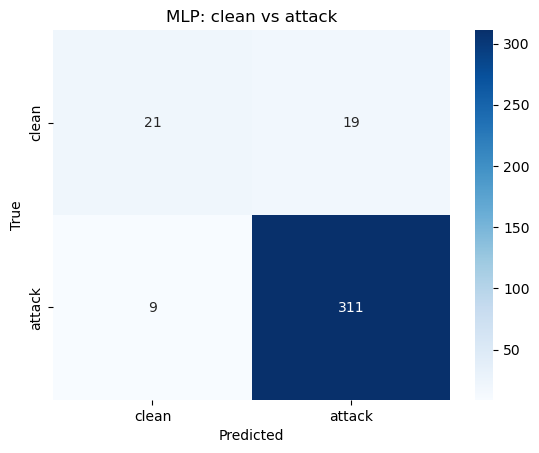

In [38]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=42
)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=['clean', 'attack']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean', 'attack'],
            yticklabels=['clean', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP: clean vs attack')
plt.show()